# Filtrado de series temporales

Este notebook prueba, sobre datos reales de Chartmetric, dos tecnicas trabajadas en la materia a partir de senales sinteticas: el filtro de media movil (`03_ Filtrado_media_movil.ipynb`) y el filtrado en el dominio de frecuencia (`Filtrado_DF.ipynb`, `04_ Filtrado_DF (1).ipynb`).

El notebook puede levantar dos datasets del notebook de Chartmetric (se elige en la celda de carga, con una opción activa y la otra comentada): el panel de la sección 16 (`artistas_ST_<n>de<n>_top5000_22_26_na_wide.csv`: 5 variables, marco top 5000, marzo 2022 a marzo 2026, grilla regular con NA explícitos) o el dataset crudo completo (`artistas_ST_raw_<n>_wide.csv`: todas las variables, todo el período, sin recorte). La muestra sigue creciendo, asi que este notebook no fija artistas por ID: los selecciona de manera programatica en cada corrida, para poder reutilizarlo sin cambios a medida que el dataset se actualice con mas artistas.

In [15]:
# PAQUETES

library(data.table)


## 1. Configuracion y carga de datos

In [16]:
# ============================================================
# CONFIGURACION
# ============================================================

# Archivos de entrada (salidas del notebook de Chartmetric).
# La celda de carga levanta uno de los dos; el otro queda
# comentado.
# - Panel (sección 16): 5 variables, marco top 5000, marzo 2022
#   a marzo 2026, grilla regular con NA explícitos.
# - Crudo: todas las variables, todo el período, sin recorte.
ARCHIVO_PANEL_WIDE <- "artistas_ST_1041de1424_top5000_22_26_na_wide.csv"
ARCHIVO_RAW_WIDE <- "artistas_ST_raw_2000_wide.csv"

FIGURES_DIR <- "figuras"

dir.create(
  FIGURES_DIR,
  showWarnings = FALSE,
  recursive = TRUE
)

# Semilla para la seleccion de artistas ilustrativos (bloque 2).
# Se sugiere repetir la seleccion con otras semillas para chequear
# que los patrones observados no dependan del artista puntual sorteado.
SEMILLA_SELECCION_ARTISTAS <- 2026

cat(
  "Panel:", ARCHIVO_PANEL_WIDE, "\n",
  "Crudo:", ARCHIVO_RAW_WIDE, "\n",
  "Directorio de figuras:", FIGURES_DIR, "\n"
)

Dataset mensual: 2000_artistas_ST_wide.csv 
Directorio de figuras: figuras 


In [17]:
# ============================================================
# CARGA DEL DATASET MENSUAL (FORMATO ANCHO)
#
# Dejar activa una sola de las dos opciones. Cada una define el
# objeto con su propio nombre, lo asigna a pilotos_wide (el
# nombre que usa el resto del notebook) y fija la variable
# ilustrativa, porque los nombres de variables difieren entre
# los dos archivos.
# ============================================================

# Opción A (activa): panel de la sección 16
artistas_panel_wide <- fread(ARCHIVO_PANEL_WIDE)
pilotos_wide <- artistas_panel_wide
VARIABLE_ILUSTRATIVA <- "spotify_followers"
ETIQUETA_VARIABLE_ILUSTRATIVA <- "Seguidores en Spotify"

# Opción B: dataset crudo completo
# artistas_raw_wide <- fread(ARCHIVO_RAW_WIDE)
# pilotos_wide <- artistas_raw_wide
# VARIABLE_ILUSTRATIVA <- "fan_stats__spotify__listeners"
# ETIQUETA_VARIABLE_ILUSTRATIVA <- "Oyentes mensuales en Spotify"

pilotos_wide[
  ,
  month := as.Date(month)
]

setorder(
  pilotos_wide,
  artist_id,
  month
)

cat(
  "Variable ilustrativa:", VARIABLE_ILUSTRATIVA, "\n"
)

dim(pilotos_wide)

[1] 123895     28

In [18]:
# ------------------------------------------------------------
# CONTROL: dimensiones, periodo y cobertura general por variable
# ------------------------------------------------------------

cat(
  "Artistas:",
  uniqueN(pilotos_wide$artist_id),
  "\n"
)

cat(
  "Meses:",
  uniqueN(pilotos_wide$month),
  "\n"
)

cat(
  "Periodo:",
  format(min(pilotos_wide$month)),
  "a",
  format(max(pilotos_wide$month)),
  "\n\n"
)

# Columnas de series: todas menos las de identificación, así el
# control funciona con los nombres de cualquiera de los dos
# archivos
variables_series <- setdiff(
  names(pilotos_wide),
  c("artist_id", "artist_name", "cm_artist_rank", "decil_marco", "month")
)

na_por_variable <- pilotos_wide[
  ,
  lapply(
    .SD,
    function(x) round(100 * mean(is.na(x)), 1)
  ),
  .SDcols = variables_series
]

melt(
  na_por_variable,
  measure.vars = variables_series,
  variable.name = "variable",
  value.name = "pct_na"
)[
  order(pct_na)
]

Artistas: 2000 
Meses: 63 
Periodo: 2021-01-01 a 2026-03-01 



variable,pct_na
<fct>,<dbl>
fan_stats__spotify__followers,1.2
fan_stats__spotify__listeners,1.2
fan_stats__instagram__followers,17.2
fan_stats__youtube_channel__views,17.2
fan_stats__youtube_channel__subscribers,17.9
fan_stats__youtube_artist__monthly_views,30.6
fan_stats__twitter__followers,31.8
fan_stats__tiktok__followers,51.3
fan_stats__tiktok__likes,52.1


La variable ilustrativa para probar los filtros se fija en la celda de carga, según el dataset elegido. Con el panel se usa `spotify_followers`, la variable del panel con menor proporción de nulos. Con el dataset crudo se usa `fan_stats__spotify__listeners`, que no forma parte del panel pero tiene cobertura equivalente.

## 2. Seleccion de artistas ilustrativos

Mostrar todas las trayectorias a la vez produce un grafico de espagueti dificil de leer (senalado en data-to-viz.com para graficos de lineas con demasiadas series). Para ilustrar los filtros alcanza con un puñado de artistas con cobertura completa en la variable elegida.

La seleccion replica la logica de estratificacion por rank ya usada para armar la muestra de artistas (terciles en lugar de deciles, dado que aca el objetivo es solo ilustrar, no representar a toda la poblacion): se sortea un artista de cada tercil de `cm_artist_rank` entre los que tienen cobertura completa, para comparar trayectorias de artistas de alto, medio y bajo rank de popularidad.

In [19]:
# ============================================================
# SELECCION DE ARTISTAS ILUSTRATIVOS
# (VARIABLE_ILUSTRATIVA se define en la celda de carga)
# ============================================================

total_meses_dataset <- uniqueN(pilotos_wide$month)

cobertura_por_artista <- pilotos_wide[
  ,
  .(
    n_meses = .N,
    n_na = sum(is.na(get(VARIABLE_ILUSTRATIVA)))
  ),
  by = .(
    artist_id,
    artist_name,
    cm_artist_rank
  )
]

artistas_cobertura_completa <- cobertura_por_artista[
  n_meses == total_meses_dataset &
    n_na == 0
]

cat(
  "Artistas con cobertura completa en",
  VARIABLE_ILUSTRATIVA,
  ":",
  nrow(artistas_cobertura_completa),
  "de",
  nrow(cobertura_por_artista),
  "\n"
)

# Terciles por posicion (no por valor de rank), para no depender
# de que los cortes de quantile caigan en valores repetidos.
artistas_cobertura_completa[
  ,
  tercil_rank := cut(
    frank(
      cm_artist_rank,
      ties.method = "first"
    ),
    breaks = quantile(
      frank(
        cm_artist_rank,
        ties.method = "first"
      ),
      probs = c(0, 1/3, 2/3, 1)
    ),
    include.lowest = TRUE,
    labels = c("rank_alto", "rank_medio", "rank_bajo")
  )
]

set.seed(
  SEMILLA_SELECCION_ARTISTAS
)

artistas_ilustrativos <- artistas_cobertura_completa[
  ,
  .SD[sample(.N, 1)],
  by = tercil_rank
]

artistas_ilustrativos[
  ,
  .(
    artist_id,
    artist_name,
    cm_artist_rank,
    tercil_rank
  )
]

Artistas con cobertura completa en fan_stats__spotify__listeners : 1793 de 2000 


artist_id,artist_name,cm_artist_rank,tercil_rank
<int>,<chr>,<int>,<fct>
7848,The Walters,2705,rank_alto
1723175,Kayla Nicole,5651,rank_medio
30318,The Psychedelic Furs,10303,rank_bajo


In [20]:
# ------------------------------------------------------------
# Subconjunto de datos para los artistas ilustrativos
# ------------------------------------------------------------

ids_ilustrativos <- artistas_ilustrativos$artist_id

series_ilustrativas <- pilotos_wide[
  artist_id %in% ids_ilustrativos,
  .(
    artist_id,
    artist_name,
    month,
    valor = get(VARIABLE_ILUSTRATIVA)
  )
]

series_ilustrativas <- merge(
  series_ilustrativas,
  artistas_ilustrativos[
    ,
    .(
      artist_id,
      tercil_rank
    )
  ],
  by = "artist_id"
)

setorder(
  series_ilustrativas,
  tercil_rank,
  month
)

# reordenar ids_ilustrativos siguiendo el orden de aparicion
# en series_ilustrativas, para que lineas y leyenda coincidan
ids_ilustrativos <- unique(
  series_ilustrativas$artist_id
)

nrow(series_ilustrativas)


[1] 189

agg_record_82383950967 
                     2

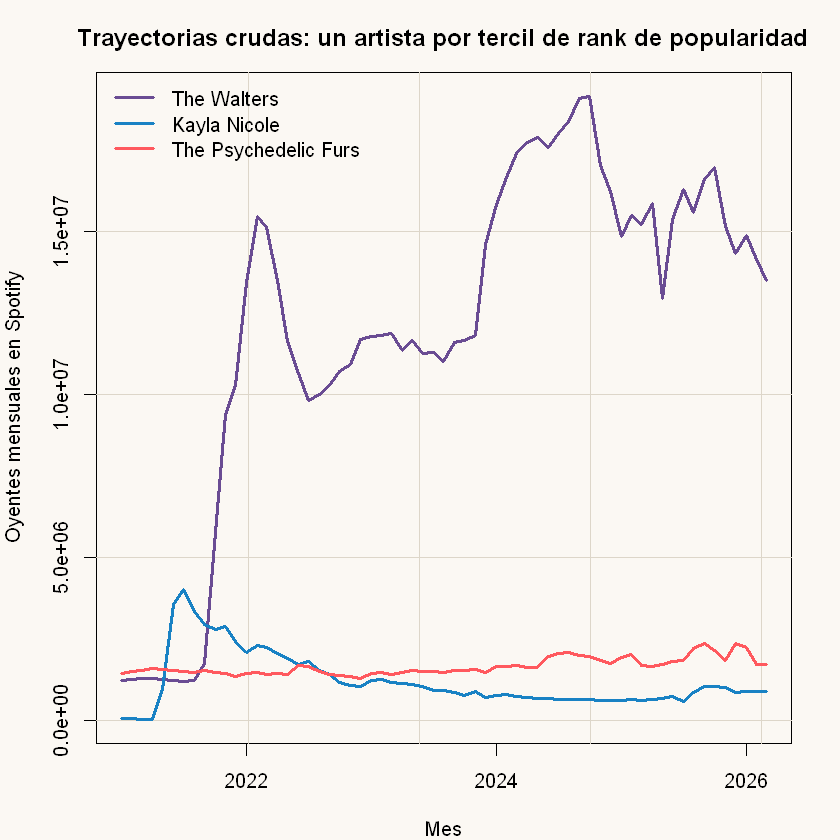

In [21]:
# ============================================================
# GRAFICO 1: trayectorias crudas de los artistas ilustrativos
# ============================================================

PALETA_ARTISTAS <- c(
  rank_alto  = "#6A4C93",
  rank_medio = "#1982C4",
  rank_bajo  = "#FF595E"
)

leyenda_artistas <- unique(
  series_ilustrativas[
    ,
    .(
      artist_id,
      artist_name,
      tercil_rank
    )
  ]
)[
  match(
    ids_ilustrativos,
    artist_id
  )
]

grafico_series_crudas <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    series_ilustrativas$month,
    series_ilustrativas$valor,
    type = "n",
    xlab = "Mes",
    ylab = ETIQUETA_VARIABLE_ILUSTRATIVA,
    main = "Trayectorias crudas: un artista por tercil de rank de popularidad"
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )

  for (artista_id in ids_ilustrativos) {

    serie_artista <- series_ilustrativas[
      artist_id == artista_id
    ]

    color_artista <- PALETA_ARTISTAS[
      as.character(serie_artista$tercil_rank[1])
    ]

    lines(
      serie_artista$month,
      serie_artista$valor,
      col = color_artista,
      lwd = 2.5
    )
  }

  legend(
    "topleft",
    legend = leyenda_artistas$artist_name,
    col = PALETA_ARTISTAS[
      as.character(leyenda_artistas$tercil_rank)
    ],
    lwd = 2.5,
    bty = "n"
  )
}

grafico_series_crudas()

png(
  file.path(
    FIGURES_DIR,
    "01_series_crudas_artistas_ilustrativos.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_series_crudas()
dev.off()

## 3. Filtro de media movil (ventanas mensuales)

Adaptacion de `03_ Filtrado_media_movil.ipynb`, con dos cambios frente al original:

1. Las ventanas se expresan en meses (3, 6 y 12, aproximando trimestre, semestre y anio) en lugar de dias (3, 7, 15, 25 en el notebook del profesor), porque el dataset ya esta mensualizado.
2. Se usa `frollmean` de data.table en lugar de `filter(..., circular = TRUE)`. Una trayectoria de artista no es periodica, asi que un filtro circular pegaria diciembre con enero de manera artificial; `frollmean` ademas admite `na.rm` para los meses con dato faltante, algo que las series reales de Chartmetric sí tienen.

In [22]:
# ============================================================
# MEDIAS MOVILES POR ARTISTA (ventanas de 3, 6 y 12 meses)
# ============================================================

VENTANAS_MEDIA_MOVIL <- c(3, 6, 12)

# Con ventana par, el centrado de frollmean queda levemente asimetrico
# (un mes mas hacia el pasado que hacia el futuro). Se acepta esa
# asimetria menor a cambio de ventanas con lectura directa en meses
# (trimestre, semestre, anio).

series_ilustrativas_suavizadas <- copy(
  series_ilustrativas
)

setorder(
  series_ilustrativas_suavizadas,
  artist_id,
  month
)

for (ventana in VENTANAS_MEDIA_MOVIL) {

  nombre_columna <- paste0(
    "media_movil_",
    ventana,
    "m"
  )

  series_ilustrativas_suavizadas[
    ,
    (nombre_columna) := frollmean(
      valor,
      n = ventana,
      align = "center",
      na.rm = TRUE
    ),
    by = artist_id
  ]
}


In [23]:
# ------------------------------------------------------------
# CONTROL: primeras filas de un artista, serie cruda junto a las
# tres medias moviles, para confirmar que el suavizado es razonable
# ------------------------------------------------------------

series_ilustrativas_suavizadas[
  artist_id == ids_ilustrativos[1]
][
  1:15
]


artist_id,artist_name,month,valor,tercil_rank,media_movil_3m,media_movil_6m,media_movil_12m
<int>,<chr>,<date>,<int>,<fct>,<dbl>,<dbl>,<dbl>
7848,The Walters,2021-01-01,1206787,rank_alto,NA,NA,NA
7848,The Walters,2021-02-01,1243404,rank_alto,1245908,NA,NA
7848,The Walters,2021-03-01,1287534,rank_alto,1271944,1247279,NA
7848,The Walters,2021-04-01,1284895,rank_alto,1273295,1242908,NA
7848,The Walters,2021-05-01,1247457,rank_alto,1248649,1237809,NA
7848,The Walters,2021-06-01,1213596,rank_alto,1213871,1311902,3085632
7848,The Walters,2021-07-01,1180559,rank_alto,1202323,2059539,4104578
7848,The Walters,2021-08-01,1212814,rank_alto,1375154,3414930,5288227
7848,The Walters,2021-09-01,1732089,rank_alto,2905206,4923986,6438922


agg_record_82385f764182 
                      2

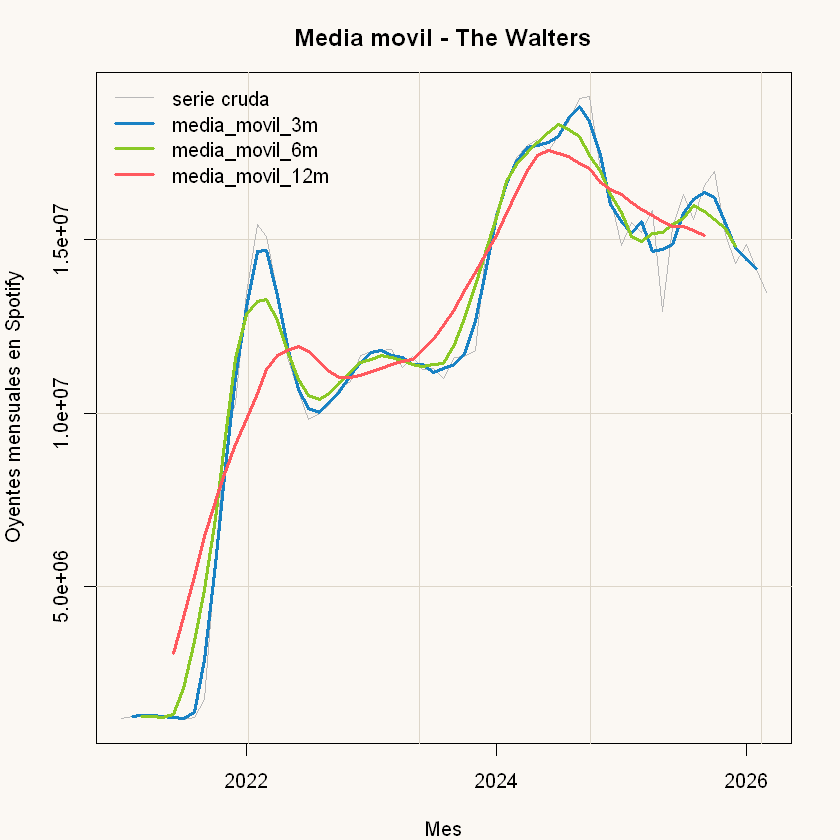

In [24]:
# ============================================================
# GRAFICO 2: medias moviles sobre un artista ilustrativo
# ============================================================

artista_foco <- ids_ilustrativos[1]

serie_foco <- series_ilustrativas_suavizadas[
  artist_id == artista_foco
]

PALETA_VENTANAS <- c(
  media_movil_3m  = "#1982C4",
  media_movil_6m  = "#8AC926",
  media_movil_12m = "#FF595E"
)

grafico_medias_moviles <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    serie_foco$month,
    serie_foco$valor,
    type = "n",
    xlab = "Mes",
    ylab = ETIQUETA_VARIABLE_ILUSTRATIVA,
    main = paste(
      "Media movil -",
      serie_foco$artist_name[1]
    )
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )

  lines(
    serie_foco$month,
    serie_foco$valor,
    col = "#B8B8B8",
    lwd = 1
  )

  for (columna_ventana in names(PALETA_VENTANAS)) {

    lines(
      serie_foco$month,
      serie_foco[[columna_ventana]],
      col = PALETA_VENTANAS[columna_ventana],
      lwd = 2.5
    )
  }

  legend(
    "topleft",
    legend = c("serie cruda", names(PALETA_VENTANAS)),
    col = c("#B8B8B8", unname(PALETA_VENTANAS)),
    lwd = c(1, 2.5, 2.5, 2.5),
    bty = "n"
  )
}

grafico_medias_moviles()

png(
  file.path(
    FIGURES_DIR,
    "02_media_movil_artista_foco.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_medias_moviles()
dev.off()

## 4. Filtro en el dominio de frecuencia (FFT)

Adaptacion de `Filtrado_DF.ipynb` y `04_ Filtrado_DF (1).ipynb`. La FFT necesita una serie completa y equiespaciada, sin huecos, por eso se trabaja sobre el mismo artista foco de la seccion anterior (cobertura completa garantizada por la seleccion del bloque 2). Variables con huecos frecuentes, como Twitter en el pozo de fines de 2023 detectado en el notebook principal, necesitarian primero una imputacion antes de poder aplicar este filtro.

El filtro que se construye aca es pasa-bajos: conserva las frecuencias bajas (la tendencia) y anula las altas (variacion mes a mes). Es el complemento del `filtroDF` del notebook de la materia, que anulaba las frecuencias bajas para aislar una componente de alta frecuencia escondida en una señal sintetica; aca el objetivo es el opuesto, recuperar la tendencia de una serie real.

agg_record_823840164a05 
                      2

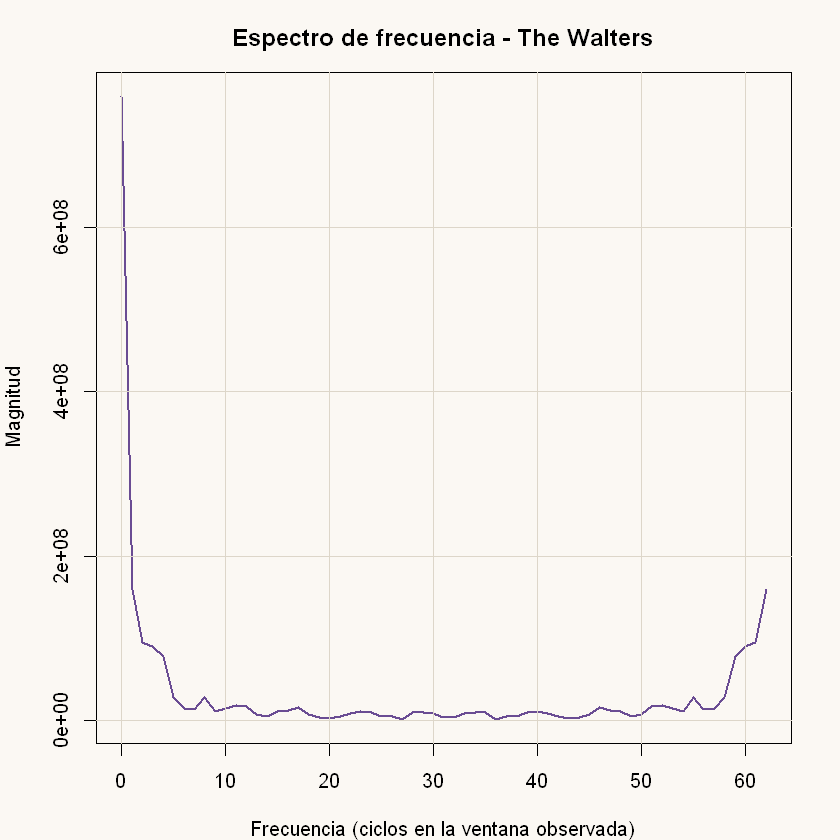

In [25]:
# ============================================================
# ESPECTRO DE FRECUENCIA DE LA SERIE FOCO
# ============================================================

n_meses_serie_foco <- nrow(serie_foco)

fft_serie_foco <- fft(
  serie_foco$valor
)

espectro_serie_foco <- Mod(
  fft_serie_foco
)

grafico_espectro <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    0:(n_meses_serie_foco - 1),
    espectro_serie_foco,
    type = "l",
    col = "#6A4C93",
    lwd = 2,
    xlab = "Frecuencia (ciclos en la ventana observada)",
    ylab = "Magnitud",
    main = paste(
      "Espectro de frecuencia -",
      serie_foco$artist_name[1]
    )
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )
}

grafico_espectro()

png(
  file.path(
    FIGURES_DIR,
    "03_espectro_frecuencia_artista_foco.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_espectro()
dev.off()


In [26]:
# ============================================================
# FILTRO PASA-BAJOS (dominio de frecuencia) SOBRE LA SERIE FOCO
# ============================================================

# Cantidad de armonicos de baja frecuencia que se conservan,
# ademas de la componente continua (frecuencia cero).
BANDA_FILTRO_PASA_BAJOS <- 6

filtro_pasa_bajos <- rep(
  0,
  n_meses_serie_foco
)

filtro_pasa_bajos[
  1:(BANDA_FILTRO_PASA_BAJOS + 1)
] <- 1

filtro_pasa_bajos[
  (n_meses_serie_foco - BANDA_FILTRO_PASA_BAJOS + 1):n_meses_serie_foco
] <- 1

fft_serie_foco_filtrada <- filtro_pasa_bajos * fft_serie_foco

serie_foco_tendencia_fft <- Re(
  fft(
    fft_serie_foco_filtrada,
    inverse = TRUE
  ) / n_meses_serie_foco
)


In [27]:
# ------------------------------------------------------------
# CONTROL: la reconstruccion conserva el largo de la serie original
# y queda en la misma escala (sin corrimientos de magnitud)
# ------------------------------------------------------------

cat(
  "Largo serie original:",
  length(serie_foco$valor),
  "\n"
)

cat(
  "Largo serie reconstruida:",
  length(serie_foco_tendencia_fft),
  "\n\n"
)

summary(
  serie_foco$valor
)

summary(
  serie_foco_tendencia_fft
)


Largo serie original: 63 
Largo serie reconstruida: 63 



    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 1180559 10659864 12942984 12052706 15697050 19115200 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 -499652 10566153 12655945 12052706 15776125 18398725 

agg_record_82385af77c82 
                      2

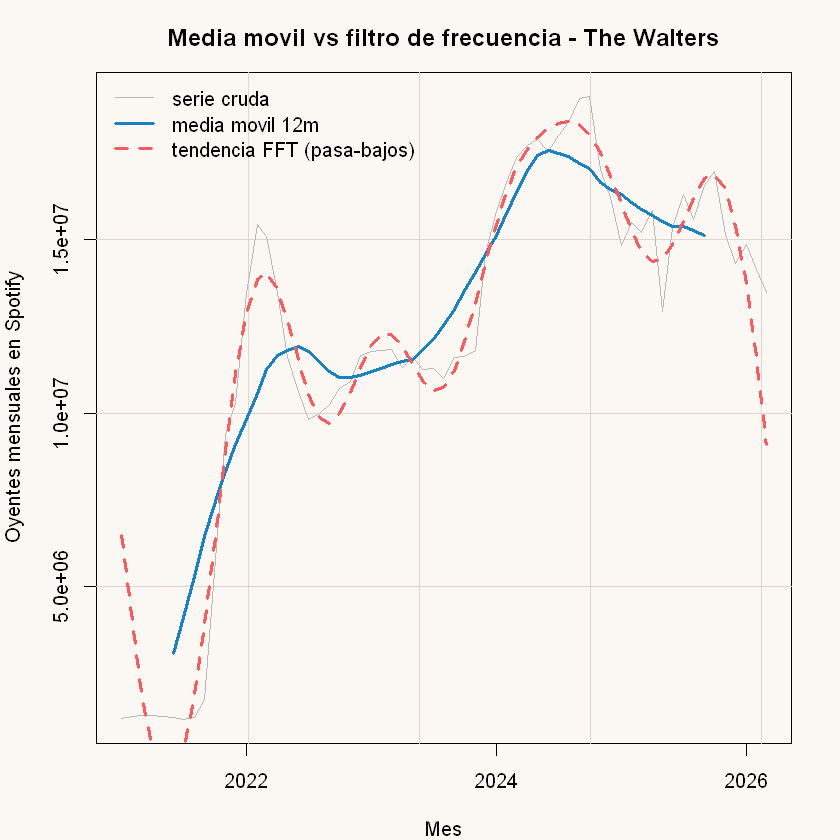

In [28]:
# ============================================================
# GRAFICO 3: media movil vs filtro de frecuencia, mismo artista
# ============================================================

grafico_comparacion_filtros <- function() {

  par(
    bg = "#FBF8F3",
    mar = c(4, 4, 3, 2)
  )

  plot(
    serie_foco$month,
    serie_foco$valor,
    type = "n",
    xlab = "Mes",
    ylab = ETIQUETA_VARIABLE_ILUSTRATIVA,
    main = paste(
      "Media movil vs filtro de frecuencia -",
      serie_foco$artist_name[1]
    )
  )

  grid(
    col = "#DDD6C9",
    lty = 1
  )

  lines(
    serie_foco$month,
    serie_foco$valor,
    col = "#B8B8B8",
    lwd = 1
  )

  lines(
    serie_foco$month,
    serie_foco$media_movil_12m,
    col = "#1982C4",
    lwd = 2.5
  )

  lines(
    serie_foco$month,
    serie_foco_tendencia_fft,
    col = "#FF595E",
    lwd = 2.5,
    lty = 2
  )

  legend(
    "topleft",
    legend = c(
      "serie cruda",
      "media movil 12m",
      "tendencia FFT (pasa-bajos)"
    ),
    col = c("#B8B8B8", "#1982C4", "#FF595E"),
    lwd = c(1, 2.5, 2.5),
    lty = c(1, 1, 2),
    bty = "n"
  )
}

grafico_comparacion_filtros()

png(
  file.path(
    FIGURES_DIR,
    "04_comparacion_media_movil_vs_fft.png"
  ),
  width = 1400,
  height = 900,
  res = 150
)
grafico_comparacion_filtros()
dev.off()

## 6. Figura para la presentación

Las cinco variables del panel, series crudas, para dos artistas que contrastan en nivel y en forma: Ed Sheeran (trayectoria consolidada y estable) y Peso Pluma (crecimiento explosivo en 2023), ambos del decil 1. Un panel por variable, porque miden cosas distintas y difieren en órdenes de magnitud. La escala logarítmica permite ver las dos formas a la vez; la separación vertical entre las líneas muestra por qué las series necesitan una transformación antes de medir similaridad. Requiere la opción A (panel) activa en la celda de carga.

In [ ]:
# ============================================================
# FIGURA PARA PRESENTACIÓN: LAS CINCO VARIABLES DEL PANEL,
# SERIES CRUDAS, PARA DOS ARTISTAS CONTRASTANTES
#
# Un panel por variable (las cinco miden cosas distintas y
# difieren en órdenes de magnitud, así que no comparten eje).
# Escala logarítmica en y: los dos artistas difieren en nivel,
# y en escala lineal la serie más chica quedaría aplastada.
# Artistas reconocibles y de trayectorias opuestas, ambos del
# decil 1: uno consolidado y estable, y uno con crecimiento
# explosivo en 2023. Peso Pluma no tiene datos de Instagram en
# los primeros 9 meses: la línea arranca más tarde en ese panel.
# ============================================================

ARTISTAS_FIGURA_PRESENTACION <- c(
  "3648",     # Ed Sheeran, trayectoria estable
  "4251908"   # Peso Pluma, crecimiento explosivo en 2023
)

VARIABLES_FIGURA_PRESENTACION <- c(
  spotify_followers = "Seguidores en Spotify",
  instagram_followers = "Seguidores en Instagram",
  spotify_playlist_count = "Playlists en Spotify",
  youtube_channel_subscribers = "Suscriptores en YouTube",
  youtube_playlist_count = "Playlists en YouTube"
)

# Paleta validada para daltonismo y contraste sobre el fondo #FBF8F3
PALETA_ARTISTAS_FIGURA <- c("#1982C4", "#F04A50")

stopifnot(
  "La figura usa el panel: activar la opción A en la celda de carga" =
    exists("artistas_panel_wide")
)

# Eje x fijo en la ventana del panel, con marcas en marzo de cada
# año: el inicio de la ventana queda marcado y los meses sin dato
# al comienzo de una serie se ven como espacio vacío
LIMITES_X_FIGURA <- as.Date(c("2022-03-01", "2026-03-01"))
MARCAS_X_FIGURA <- seq(LIMITES_X_FIGURA[1], LIMITES_X_FIGURA[2], by = "year")

series_figura_presentacion <- artistas_panel_wide[
  artist_id %in% ARTISTAS_FIGURA_PRESENTACION
][
  order(match(artist_id, ARTISTAS_FIGURA_PRESENTACION), month)
]

nombres_artistas_figura <- series_figura_presentacion[
  ,
  .(artist_name = artist_name[1], decil_marco = decil_marco[1]),
  by = artist_id
][
  match(ARTISTAS_FIGURA_PRESENTACION, artist_id)
]

# Etiquetas del eje y en millones o miles, sin notación científica
etiqueta_eje_log <- function(x) {
  numero <- function(v) formatC(v, format = "fg", digits = 3, big.mark = ".", decimal.mark = ",")
  ifelse(
    x >= 1e6,
    paste0(numero(x / 1e6), " M"),
    ifelse(
      x >= 1e3,
      paste0(numero(x / 1e3), " mil"),
      numero(x)
    )
  )
}

grafico_cinco_variables <- function() {

  par(
    mfrow = c(1, 5),
    bg = "#FBF8F3",
    mar = c(3, 4.2, 3, 1),
    oma = c(0, 0, 4.5, 0),
    las = 1,
    cex.axis = 0.9
  )

  for (variable_figura in names(VARIABLES_FIGURA_PRESENTACION)) {

    valores <- series_figura_presentacion[[variable_figura]]

    plot(
      series_figura_presentacion$month,
      valores,
      type = "n",
      log = "y",
      xlim = LIMITES_X_FIGURA,
      xlab = "",
      ylab = "",
      xaxt = "n",
      yaxt = "n",
      bty = "n",
      main = VARIABLES_FIGURA_PRESENTACION[[variable_figura]],
      font.main = 1,
      cex.main = 1.15
    )

    axis(
      1,
      at = MARCAS_X_FIGURA,
      labels = paste("mar", format(MARCAS_X_FIGURA, "%Y")),
      col = NA,
      col.ticks = "#B8B0A2"
    )

    marcas_y <- axTicks(2)

    axis(
      2,
      at = marcas_y,
      labels = etiqueta_eje_log(marcas_y),
      col = NA,
      col.ticks = NA
    )

    abline(
      h = marcas_y,
      col = "#E6E0D5",
      lwd = 1
    )

    for (i in seq_along(ARTISTAS_FIGURA_PRESENTACION)) {

      serie_artista <- series_figura_presentacion[
        artist_id == ARTISTAS_FIGURA_PRESENTACION[i]
      ]

      lines(
        serie_artista$month,
        serie_artista[[variable_figura]],
        col = PALETA_ARTISTAS_FIGURA[i],
        lwd = 2.5
      )
    }
  }

  mtext(
    "Las cinco variables del panel, series crudas mensuales (marzo 2022 a marzo 2026, escala logarítmica)",
    side = 3,
    outer = TRUE,
    line = 2.6,
    cex = 1.1
  )

  par(fig = c(0, 1, 0, 1), oma = c(0, 0, 0, 0), mar = c(0, 0, 0, 0), new = TRUE)

  plot(0, 0, type = "n", bty = "n", xaxt = "n", yaxt = "n")

  legend(
    "top",
    legend = nombres_artistas_figura$artist_name,
    col = PALETA_ARTISTAS_FIGURA,
    lwd = 2.5,
    horiz = TRUE,
    bty = "n",
    inset = c(0, 0.075),
    cex = 1.05,
    text.width = NA
  )
}

grafico_cinco_variables()

png(
  file.path(
    FIGURES_DIR,
    "05_cinco_variables_dos_artistas.png"
  ),
  width = 3000,
  height = 950,
  res = 200
)
grafico_cinco_variables()
dev.off()

## 5. Que queda pendiente

1. Extender el suavizado (media movil y/o pasa-bajos) a las variables restantes y a toda la muestra, no solo a los tres artistas ilustrativos, una vez definido con que variables se arma el clustering.
2. Resolver el tratamiento de series con huecos (Twitter, TikTok) antes de poder aplicarles FFT; la media movil con `na.rm = TRUE` tolera huecos aislados pero no reemplaza una estrategia de imputacion.
3. Decidir si el insumo del clustering va a ser la serie cruda, la tendencia filtrada, el residuo (cruda menos tendencia) o alguna combinacion de las tres.
4. Repetir la seleccion de artistas ilustrativos con otras semillas (variando `SEMILLA_SELECCION_ARTISTAS`) para chequear que los patrones observados no dependan del artista puntual sorteado en cada tercil.
5. Volver a correr este notebook cuando el panel o el dataset crudo se actualicen con mas artistas (actualizar `ARCHIVO_PANEL_WIDE` y `ARCHIVO_RAW_WIDE` en la configuracion).